In [1]:
import tensorflow as tf
tensor = tf.random.uniform(
    shape=(4, 4),
    minval=1,
    maxval=51,
    dtype=tf.int32
)

print("Original Tensor:")
print(tensor)

print("\nShape:", tensor.shape)
print("Dtype:", tensor.dtype)

Original Tensor:
tf.Tensor(
[[48 12 17 25]
 [ 4 50  8  4]
 [20 46 42 31]
 [29 16 19 41]], shape=(4, 4), dtype=int32)

Shape: (4, 4)
Dtype: <dtype: 'int32'>


In [2]:
reshaped_tensor = tf.reshape(tensor, (2, 8))
print("\nReshaped Tensor (2x8):")
print(reshaped_tensor)


Reshaped Tensor (2x8):
tf.Tensor(
[[48 12 17 25  4 50  8  4]
 [20 46 42 31 29 16 19 41]], shape=(2, 8), dtype=int32)


In [3]:
tensor_sum = tf.reduce_sum(tensor)
tensor_mean = tf.reduce_mean(tensor)
tensor_max = tf.reduce_max(tensor)

print("\nSum:", tensor_sum.numpy())
print("Mean:", tensor_mean.numpy())
print("Maximum:", tensor_max.numpy())


Sum: 412
Mean: 25
Maximum: 50


In [4]:
numpy_array = tensor.numpy()

print("\nNumPy Array:")
print(numpy_array)

print("Python type:", type(numpy_array))


NumPy Array:
[[48 12 17 25]
 [ 4 50  8  4]
 [20 46 42 31]
 [29 16 19 41]]
Python type: <class 'numpy.ndarray'>


In [5]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# a) Generate dataset
x = np.arange(1, 21, dtype=np.float32)
y = 3 * x - 2

print("X values:")
print(x)

print("\nY values:")
print(y)

X values:
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]

Y values:
[ 1.  4.  7. 10. 13. 16. 19. 22. 25. 28. 31. 34. 37. 40. 43. 46. 49. 52.
 55. 58.]


In [6]:
# b) Build a single-neuron regression model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='mse'
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


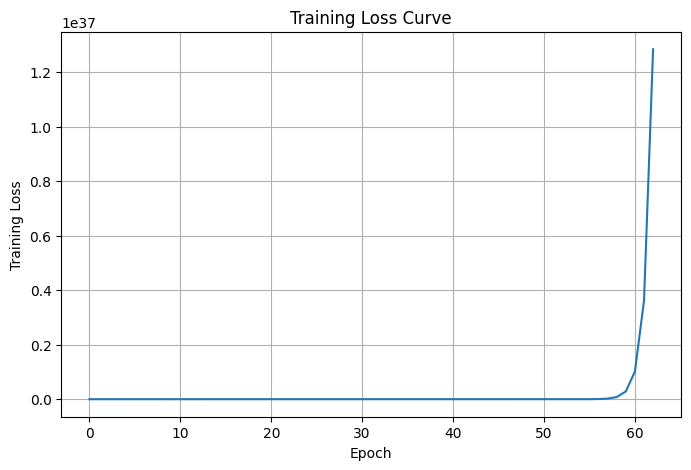

In [7]:
# c) Train the model for 200 epochs
history = model.fit(
    x, y,
    epochs=200,
    verbose=0
)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()


In [9]:
# d) Extract learned weight and bias
weight, bias = model.layers[0].get_weights()

print("Learned weight:", weight[0][0])
print("Learned bias:", bias[0])

print("\nTrue weight: 3")
print("True bias: -2")

print("\nComparison:")
print("Weight difference:", abs(weight[0][0] - 3))
print("Bias difference:", abs(bias[0] - (-2)))

Learned weight: nan
Learned bias: nan

True weight: 3
True bias: -2

Comparison:
Weight difference: nan
Bias difference: nan


In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
np.random.seed(42)
tf.random.set_seed(42)
x = np.arange(1, 11, dtype=np.float32)
y = 2 * x + 1
print("X values:")
print(x)

print("\nY values:")
print(y)

def create_model(optimizer):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(1, input_shape=(1,))
    ])

    model.compile(
        optimizer=optimizer,
        loss='mse'    )
    return model
# a) Model A with SGD
model_A = create_model(
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

# Model B with Adam
model_B = create_model(
    tf.keras.optimizers.Adam(learning_rate=0.01))

X values:
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]

Y values:
[ 3.  5.  7.  9. 11. 13. 15. 17. 19. 21.]


In [11]:
# b) Train both models for 100 epochs
history_A = model_A.fit(
    x, y,
    epochs=100,
    verbose=0
)

history_B = model_B.fit(
    x, y,
    epochs=100,
    verbose=0
)

# Record final losses
final_loss_A = history_A.history['loss'][-1]
final_loss_B = history_B.history['loss'][-1]

print("\nFinal loss after 100 epochs:")
print("Model A (SGD):", final_loss_A)
print("Model B (Adam):", final_loss_B)



Final loss after 100 epochs:
Model A (SGD): 0.035683728754520416
Model B (Adam): 2.477947235107422


In [12]:
# c) Train Model A with different epoch settings
epoch_settings = [20, 100, 500]
losses = {}
histories = {}

for epochs in epoch_settings:

    # Create a fresh model for each experiment
    model = create_model(
        tf.keras.optimizers.SGD(learning_rate=0.01)
    )

    history = model.fit(
        x, y,
        epochs=epochs,
        verbose=0
    )

    histories[epochs] = history
    losses[epochs] = history.history['loss'][-1]


print("\nModel A (SGD) final losses:")
for epochs in epoch_settings:
    print(f"{epochs} epochs: {losses[epochs]}")


Model A (SGD) final losses:
20 epochs: 0.11826898902654648
100 epochs: 0.0796726793050766
500 epochs: 0.001736033009365201


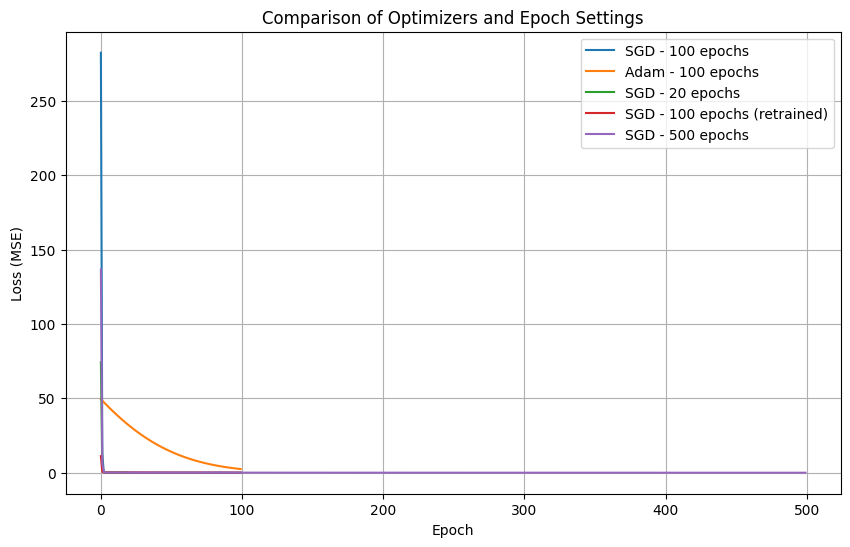

In [13]:
# d) Plot all loss curves
plt.figure(figsize=(10, 6))

# Model A - 100 epochs
plt.plot(
    history_A.history['loss'],
    label='SGD - 100 epochs'
)

# Model B - 100 epochs
plt.plot(
    history_B.history['loss'],
    label='Adam - 100 epochs'
)

# Model A - 20 epochs
plt.plot(
    histories[20].history['loss'],
    label='SGD - 20 epochs'
)

# Model A - 100 epochs
plt.plot(
    histories[100].history['loss'],
    label='SGD - 100 epochs (retrained)'
)

# Model A - 500 epochs
plt.plot(
    histories[500].history['loss'],
    label='SGD - 500 epochs'
)

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Comparison of Optimizers and Epoch Settings")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# a) Generate 200 samples
np.random.seed(42)
tf.random.set_seed(42)

x1 = np.random.uniform(0, 10, 200)
x2 = np.random.uniform(0, 10, 200)

# Small random noise
noise = np.random.normal(0, 0.5, 200)

# Target
y = 2 * x1 - 3 * x2 + 5 + noise

# Combine x1 and x2
X = np.column_stack((x1, x2))

print("First 5 input samples:")
print(X[:5])

print("\nFirst 5 target values:")
print(y[:5])

First 5 input samples:
[[3.74540119 6.42031646]
 [9.50714306 0.84139965]
 [7.31993942 1.61628714]
 [5.98658484 8.98554189]
 [1.5601864  6.0642906 ]]

First 5 target values:
[ -6.1174076   21.5005891   15.1319939  -10.13858935  -9.9104158 ]


In [15]:
# b) Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 160
Testing samples: 40



Test Loss: 15.563471794128418


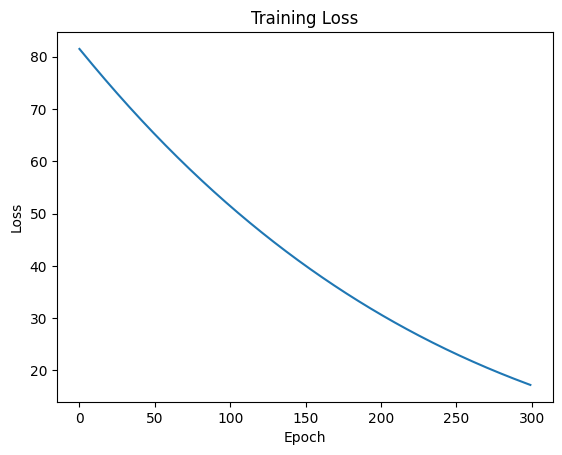

In [16]:
# c) Build a single-neuron model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=(2,))
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse'
)

# Train for 300 epochs
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    verbose=0
)

# Evaluate the model
test_loss = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nTest Loss:", test_loss)


# Plot training loss
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [17]:
# d) Extract weights and bias
weights, bias = model.layers[0].get_weights()

weight_x1 = weights[0][0]
weight_x2 = weights[1][0]
learned_bias = bias[0]

print("\nLearned Parameters:")
print("Weight for x1:", weight_x1)
print("Weight for x2:", weight_x2)
print("Bias:", learned_bias)

print("\nTrue Parameters:")
print("Weight for x1: 2")
print("Weight for x2: -3")
print("Bias: 5")


Learned Parameters:
Weight for x1: 1.3741035
Weight for x2: -1.8419061
Bias: 1.0827767

True Parameters:
Weight for x1: 2
Weight for x2: -3
Bias: 5
